Dataset para análise pode ser encontrado em: https://github.com/Victor-de-Alencar/Estudo-gcov



#Carregamento

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("resultados_experimento.csv")

#Validação

In [4]:
df.head()

,row_id,L,P,tipo,linhas_executaveis,linhas_executadas,linhas_nao_executadas,binary_tempo_ns,binary_memoria_kb,binary_iteracoes,interpolation_tempo_ns,interpolation_memoria_kb,interpolation_iteracoes,binary_interpolation_tempo_ns,binary_interpolation_memoria_kb,binary_interpolation_iteracoes,interpolation_once_binary_tempo_ns,interpolation_once_binary_memoria_kb,interpolation_once_binary_iteracoes
0,sim_001_L_1024_P_30_biased,1024,30,biased,1024,307,717,38.390,13344.0,8.074,58.284,13344.0,5.034,37.495,13344.0,2.418,29.542,13344.0,7.256
1,sim_001_L_1024_P_30_cluster,1024,30,cluster,1024,307,717,32.109,13356.0,8.213,49.045,13356.0,3.604,43.597,13356.0,2.586,52.441,13356.0,8.310
2,sim_001_L_1024_P_30_fault,1024,30,fault,1024,307,717,31.972,13476.0,8.070,42.476,13476.0,3.173,49.401,13476.0,3.006,36.863,13476.0,7.718
3,sim_001_L_1024_P_30_uniform,1024,30,uniform,1024,307,717,34.091,13728.0,8.069,39.606,13728.0,2.534,41.472,13728.0,2.360,48.350,13728.0,7.822
4,sim_001_L_1024_P_40_biased,1024,40,biased,1024,409,615,29.615,13356.0,8.376,53.815,13356.0,4.340,33.227,13356.0,2.640,28.973,13356.0,7.018


In [5]:
df.tail()

,row_id,L,P,tipo,linhas_executaveis,linhas_executadas,linhas_nao_executadas,binary_tempo_ns,binary_memoria_kb,binary_iteracoes,interpolation_tempo_ns,interpolation_memoria_kb,interpolation_iteracoes,binary_interpolation_tempo_ns,binary_interpolation_memoria_kb,binary_interpolation_iteracoes,interpolation_once_binary_tempo_ns,interpolation_once_binary_memoria_kb,interpolation_once_binary_iteracoes
9235,sim_035_L_8192_P_70_uniform,8192,70,uniform,8192,5734,2458,50.395,21640.0,11.871,37.536,21640.0,2.801,43.649,21640.0,2.749,59.230,21640.0,11.592
9236,sim_035_L_8192_P_80_biased,8192,80,biased,8192,6553,1639,47.873,21208.0,11.948,51.836,21208.0,3.529,54.924,21208.0,3.378,57.200,21208.0,11.071
9237,sim_035_L_8192_P_80_cluster,8192,80,cluster,8192,6553,1639,52.832,21172.0,11.964,69.125,21172.0,4.772,69.107,21172.0,3.996,56.802,21172.0,11.344
9238,sim_035_L_8192_P_80_fault,8192,80,fault,8192,6553,1639,52.662,21652.0,11.959,35.707,21652.0,2.786,41.610,21652.0,2.690,59.554,21652.0,11.749
9239,sim_035_L_8192_P_80_uniform,8192,80,uniform,8192,6553,1639,50.662,21324.0,11.951,33.972,21324.0,2.687,32.342,21324.0,2.663,37.405,21324.0,11.103


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   row_id                                9240 non-null   object 
 1   L                                     9240 non-null   int64  
 2   P                                     9240 non-null   int64  
 3   tipo                                  9240 non-null   object 
 4   linhas_executaveis                    9240 non-null   int64  
 5   linhas_executadas                     9240 non-null   int64  
 6   linhas_nao_executadas                 9240 non-null   int64  
 7   binary_tempo_ns                       9240 non-null   float64
 8   binary_memoria_kb                     9240 non-null   float64
 9   binary_iteracoes                      9240 non-null   float64
 10  interpolation_tempo_ns                9240 non-null   float64
 11  interpolation_mem

In [7]:
df.describe()

,L,P,linhas_executaveis,linhas_executadas,linhas_nao_executadas,binary_tempo_ns,binary_memoria_kb,binary_iteracoes,interpolation_tempo_ns,interpolation_memoria_kb,interpolation_iteracoes,binary_interpolation_tempo_ns,binary_interpolation_memoria_kb,binary_interpolation_iteracoes,interpolation_once_binary_tempo_ns,interpolation_once_binary_memoria_kb,interpolation_once_binary_iteracoes
count,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000
mean,11909.818182,55.000000,11909.818182,6549.984848,5359.833333,43.077834,16904.631169,9.599822,54.401057,16904.761905,3.654475,50.806847,16904.803463,2.942597,47.853819,16904.853247,9.042269
std,19462.764419,17.079175,19462.764419,11391.763165,9586.072253,16.014204,2514.591018,3.147170,28.798190,2514.415684,1.764110,19.018183,2514.360836,1.009008,14.323144,2514.300610,3.167642
min,64.000000,30.000000,64.000000,19.000000,13.000000,11.299000,13100.000000,3.891000,3.971000,13228.000000,0.297000,4.320000,13228.000000,0.297000,10.995000,13228.000000,1.859000
25%,256.000000,40.000000,256.000000,153.000000,128.000000,29.983000,15276.000000,6.906000,36.062750,15276.000000,2.500000,38.795000,15276.000000,2.281000,37.098500,15276.000000,6.401000
50%,2048.000000,55.000000,2048.000000,1126.000000,820.000000,42.229500,17452.000000,9.626000,46.068000,17452.000000,3.170500,49.741000,17452.000000,2.898000,49.353000,17452.000000,9.042500
75%,16384.000000,70.000000,16384.000000,6553.000000,5735.000000,55.597000,17744.000000,12.351000,65.939000,17744.000000,4.430000,60.993000,17744.000000,3.496000,59.224000,17744.000000,11.709000
max,65536.000000,80.000000,65536.000000,52428.000000,45876.000000,79.060000,21652.000000,14.962000,177.181000,21652.000000,10.941000,121.377000,21652.000000,6.226000,92.627000,21652.000000,15.367000


In [8]:
df.isnull().sum()

,0
row_id,0
L,0
P,0
tipo,0
linhas_executaveis,0
linhas_executadas,0
linhas_nao_executadas,0
binary_tempo_ns,0
binary_memoria_kb,0
binary_iteracoes,0


In [9]:
df.shape[0]

9240

## Estatísticas gerais

## Estatísticas por características

## Correlações

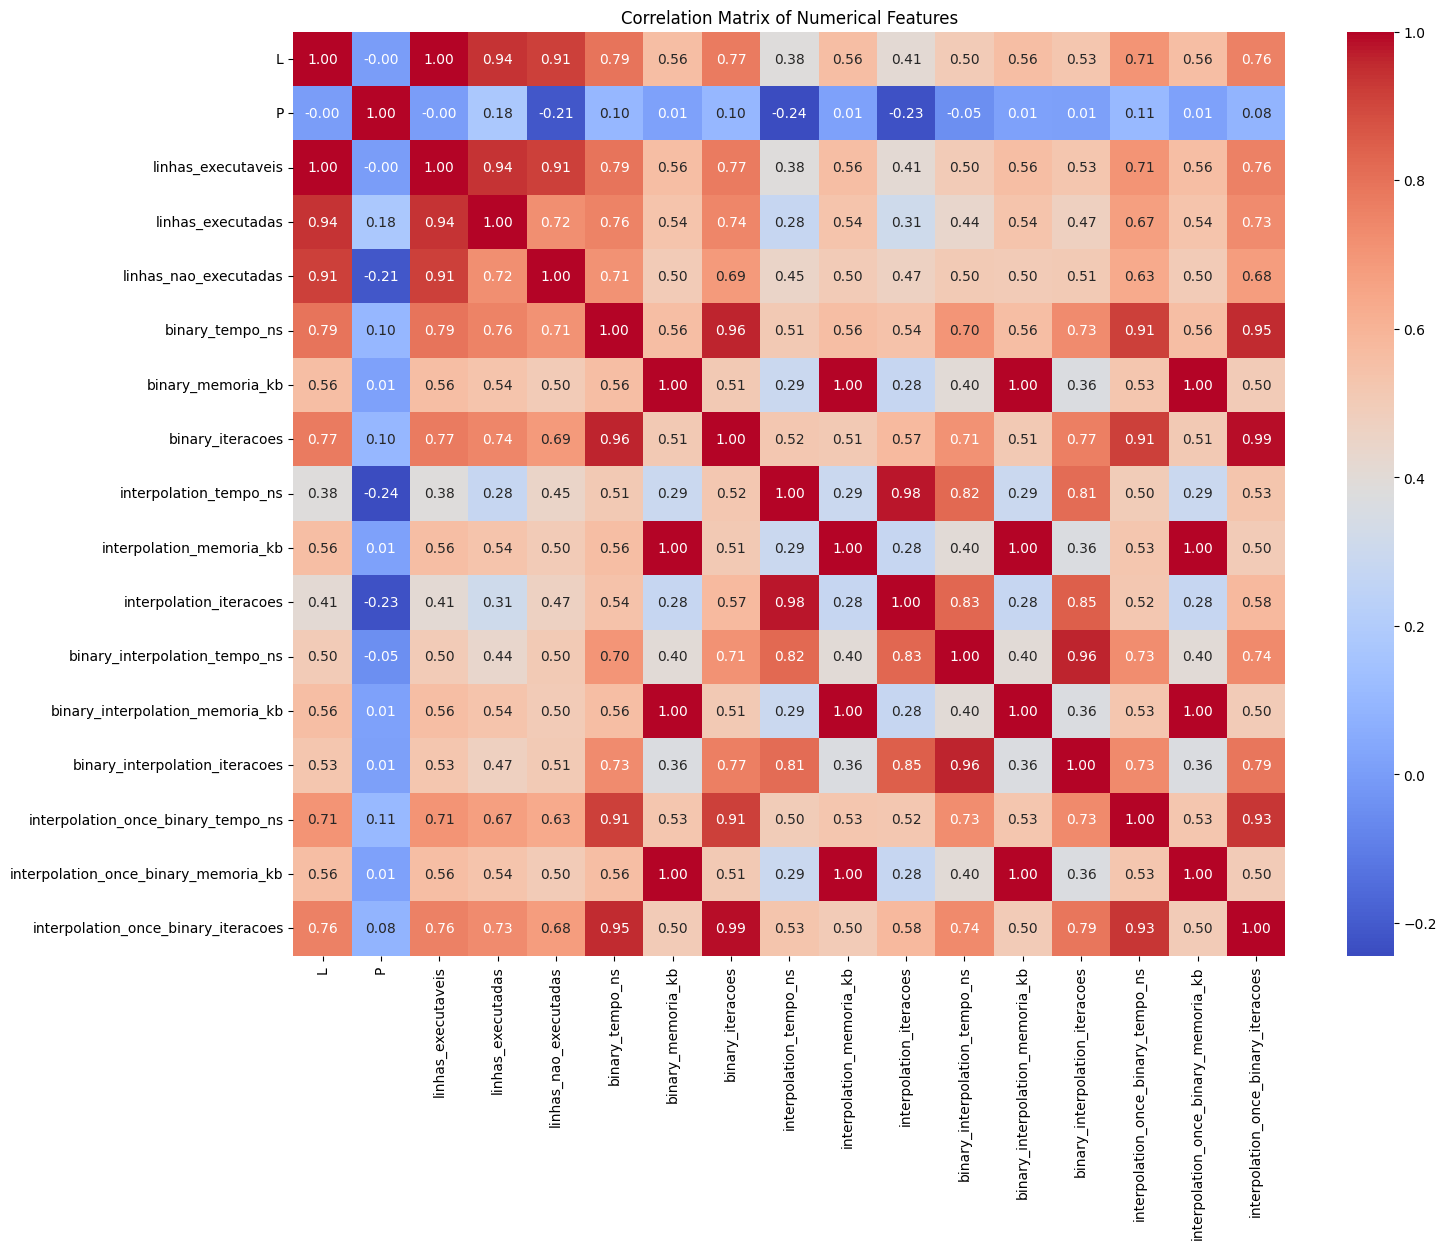

In [10]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Gráficos

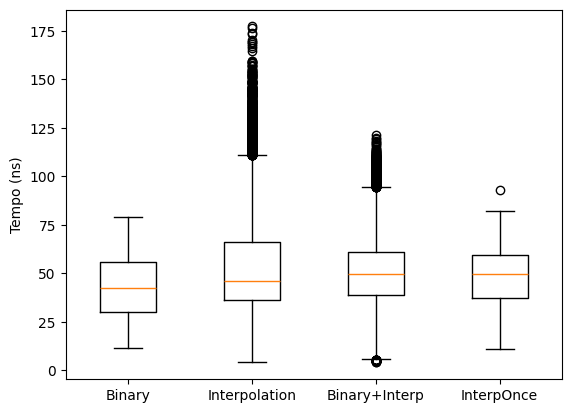

In [11]:
import matplotlib.pyplot as plt

dados = [
    df["binary_tempo_ns"],
    df["interpolation_tempo_ns"],
    df["binary_interpolation_tempo_ns"],
    df["interpolation_once_binary_tempo_ns"]
]

plt.boxplot(dados)

plt.xticks(
    [1,2,3,4],
    [
        "Binary",
        "Interpolation",
        "Binary+Interp",
        "InterpOnce"
    ]
)

plt.ylabel("Tempo (ns)")
plt.show()

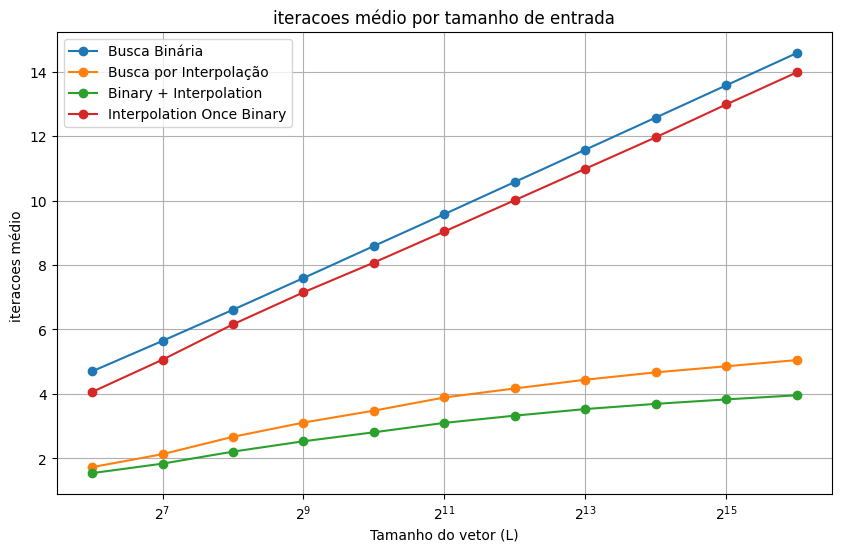

In [12]:
iteracoes_por_L = df.groupby("L").agg({
    "binary_iteracoes": "mean",
    "interpolation_iteracoes": "mean",
    "binary_interpolation_iteracoes": "mean",
    "interpolation_once_binary_iteracoes": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["binary_iteracoes"],
    marker="o",
    label="Busca Binária"
)

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["interpolation_iteracoes"],
    marker="o",
    label="Busca por Interpolação"
)

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["binary_interpolation_iteracoes"],
    marker="o",
    label="Binary + Interpolation"
)

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["interpolation_once_binary_iteracoes"],
    marker="o",
    label="Interpolation Once Binary"
)

plt.xlabel("Tamanho do vetor (L)")
plt.ylabel("iteracoes médio ")
plt.title("iteracoes médio por tamanho de entrada")

plt.legend()
plt.xscale("log", base=2)
plt.grid(True)

plt.show()

# Avaliação Experimental



## Análise Inicial



In [13]:
# Tempo geral
df[
    [
        "binary_tempo_ns",
        "interpolation_tempo_ns",
        "binary_interpolation_tempo_ns",
        "interpolation_once_binary_tempo_ns"
    ]
].mean()

,0
binary_tempo_ns,43.077834
interpolation_tempo_ns,54.401057
binary_interpolation_tempo_ns,50.806847
interpolation_once_binary_tempo_ns,47.853819


E qual tem menos iterações em média?

In [14]:
# Iterações geral
df[
    [
        "binary_iteracoes",
        "interpolation_iteracoes",
        "binary_interpolation_iteracoes",
        "interpolation_once_binary_iteracoes"
    ]
].mean()

,0
binary_iteracoes,9.599822
interpolation_iteracoes,3.654475
binary_interpolation_iteracoes,2.942597
interpolation_once_binary_iteracoes,9.042269


Como tamanho, densidade e tipo afeta esses fatores?

In [15]:
# Tempo por tamanho
df.groupby("L")[
    [
        "binary_tempo_ns",
        "interpolation_tempo_ns",
        "binary_interpolation_tempo_ns",
        "interpolation_once_binary_tempo_ns"
    ]
].mean()

,binary_tempo_ns,interpolation_tempo_ns,binary_interpolation_tempo_ns,interpolation_once_binary_tempo_ns
L,,,,
64,20.984352,26.658468,27.336873,27.573298
128,22.111862,28.379675,28.013337,27.204444
256,30.039943,42.047455,40.111987,37.980413
512,36.072339,50.160671,47.592458,44.026190
1024,33.811236,47.124582,44.091131,40.544404
2048,42.669513,58.958988,54.238898,49.118382
4096,46.567389,62.197023,57.394342,52.103185
8192,51.861746,66.283479,61.311682,55.812696
16384,56.082693,67.890163,62.461056,58.861555


## Análise do Tempo de Execução

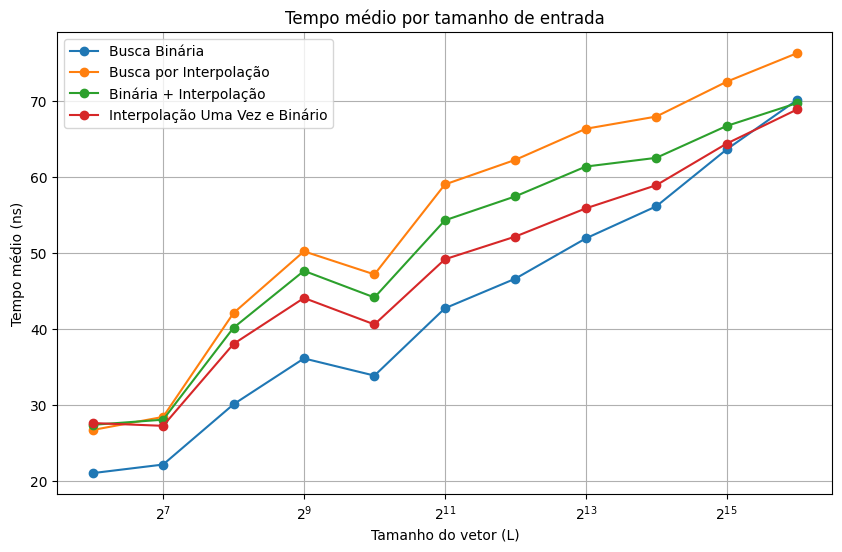

In [16]:
tempo_por_L = df.groupby("L").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_L.index,
    tempo_por_L["binary_tempo_ns"],
    marker="o",
    label="Busca Binária"
)

plt.plot(
    tempo_por_L.index,
    tempo_por_L["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação"
)

plt.plot(
    tempo_por_L.index,
    tempo_por_L["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binária + Interpolação"
)

plt.plot(
    tempo_por_L.index,
    tempo_por_L["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolação Uma Vez e Binário"
)

plt.xlabel("Tamanho do vetor (L)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por tamanho de entrada")

plt.legend()
plt.xscale("log", base=2)
plt.grid(True)

plt.show()

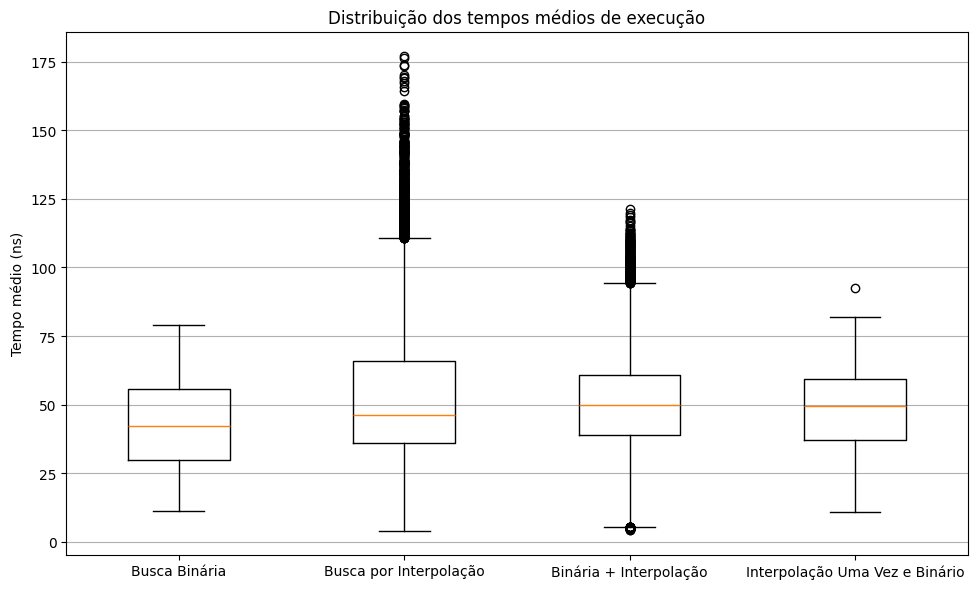

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar CSV
df = pd.read_csv("resultados_experimento.csv")

# Selecionar colunas de tempo
dados_boxplot = [
    df["binary_tempo_ns"],
    df["interpolation_tempo_ns"],
    df["binary_interpolation_tempo_ns"],
    df["interpolation_once_binary_tempo_ns"]
]

labels = [
    "Busca Binária",
    "Busca por Interpolação",
    "Binária + Interpolação",
    "Interpolação Uma Vez e Binário"
]

# Figura
plt.figure(figsize=(10, 6))

plt.boxplot(
    dados_boxplot,
    tick_labels=labels
)

plt.ylabel("Tempo médio (ns)")
plt.title("Distribuição dos tempos médios de execução")

plt.grid(True, axis="y")

plt.tight_layout()
plt.show()

In [18]:
# Tempo por densidade
df.groupby("P")[
    [
        "binary_tempo_ns",
        "interpolation_tempo_ns",
        "binary_interpolation_tempo_ns",
        "interpolation_once_binary_tempo_ns"
    ]
].mean()

,binary_tempo_ns,interpolation_tempo_ns,binary_interpolation_tempo_ns,interpolation_once_binary_tempo_ns
P,,,,
30,40.457240,64.855429,49.794453,45.209892
40,41.691118,59.853285,51.795700,46.335968
50,42.745794,57.208427,53.457495,48.068530
60,44.041597,52.385918,52.466744,48.831908
70,44.480001,47.902735,49.871562,48.848410
80,45.051253,44.200552,47.455127,49.828205


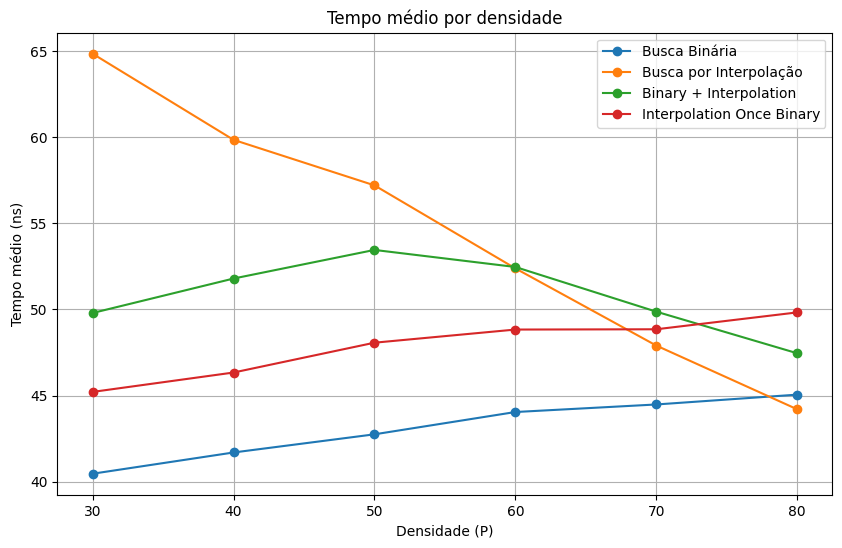

In [19]:
tempo_por_P = df.groupby("P").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_P.index,
    tempo_por_P["binary_tempo_ns"],
    marker="o",
    label="Busca Binária"
)

plt.plot(
    tempo_por_P.index,
    tempo_por_P["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação"
)

plt.plot(
    tempo_por_P.index,
    tempo_por_P["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation"
)

plt.plot(
    tempo_por_P.index,
    tempo_por_P["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary"
)

plt.xlabel("Densidade (P)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por densidade")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
# Tempo por tipo
df.groupby("tipo")[
    [
        "binary_tempo_ns",
        "interpolation_tempo_ns",
        "binary_interpolation_tempo_ns",
        "interpolation_once_binary_tempo_ns"
    ]
].mean()

,binary_tempo_ns,interpolation_tempo_ns,binary_interpolation_tempo_ns,interpolation_once_binary_tempo_ns
tipo,,,,
biased,42.554943,63.860359,51.154785,45.421277
cluster,42.956110,74.119949,61.814506,48.068710
fault,43.188504,43.330507,48.373722,48.846397
uniform,43.611778,36.293414,41.884374,49.078892


In [21]:
# Iterações por tamanho
df.groupby("L")[
    [
        "binary_iteracoes",
        "interpolation_iteracoes",
        "binary_interpolation_iteracoes",
        "interpolation_once_binary_iteracoes"
    ]
].mean()

,binary_iteracoes,interpolation_iteracoes,binary_interpolation_iteracoes,interpolation_once_binary_iteracoes
L,,,,
64,4.700568,1.728129,1.542773,4.061464
128,5.646898,2.131990,1.837307,5.063274
256,6.612570,2.669687,2.209744,6.158967
512,7.595780,3.111002,2.531133,7.152224
1024,8.589831,3.481445,2.809768,8.076164
2048,9.578629,3.889994,3.101930,9.039680
4096,10.577013,4.169850,3.326142,10.011071
8192,11.576370,4.440655,3.530254,10.985455
16384,12.573523,4.669511,3.691874,11.961249


## Análise da Quantidade de Iterações

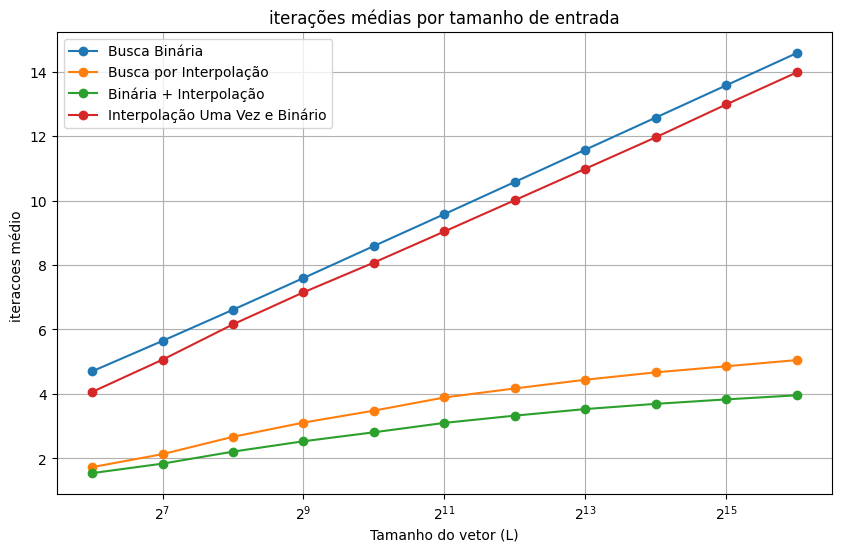

In [22]:
iteracoes_por_L = df.groupby("L").agg({
    "binary_iteracoes": "mean",
    "interpolation_iteracoes": "mean",
    "binary_interpolation_iteracoes": "mean",
    "interpolation_once_binary_iteracoes": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["binary_iteracoes"],
    marker="o",
    label="Busca Binária"
)

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["interpolation_iteracoes"],
    marker="o",
    label="Busca por Interpolação"
)

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["binary_interpolation_iteracoes"],
    marker="o",
    label="Binária + Interpolação"
)

plt.plot(
    iteracoes_por_L.index,
    iteracoes_por_L["interpolation_once_binary_iteracoes"],
    marker="o",
    label="Interpolação Uma Vez e Binário"
)

plt.xlabel("Tamanho do vetor (L)")
plt.ylabel("iteracoes médio ")
plt.title("iterações médias por tamanho de entrada")

plt.legend()
plt.xscale("log", base=2)
plt.grid(True)

plt.show()

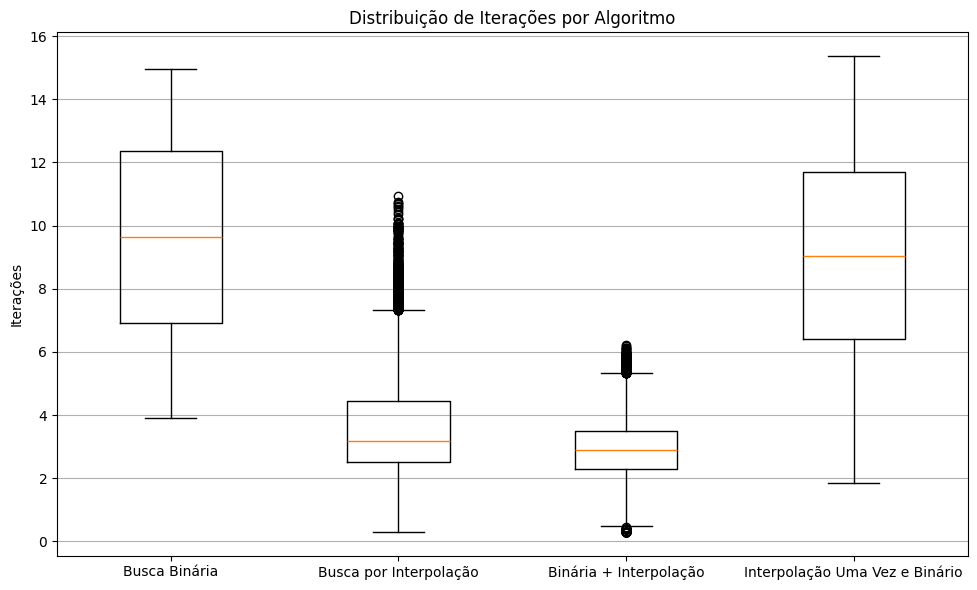

In [23]:
import matplotlib.pyplot as plt

dados_iteracoes = [
    df["binary_iteracoes"],
    df["interpolation_iteracoes"],
    df["binary_interpolation_iteracoes"],
    df["interpolation_once_binary_iteracoes"]
]

labels = [
    "Busca Binária",
    "Busca por Interpolação",
    "Binária + Interpolação",
    "Interpolação Uma Vez e Binário"
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    dados_iteracoes,
    tick_labels=labels
)

plt.ylabel("Iterações")
plt.title("Distribuição de Iterações por Algoritmo")

plt.grid(True, axis="y")

plt.tight_layout()
plt.show()

In [24]:
# Iterações por densidade
df.groupby("P")[
    [
        "binary_iteracoes",
        "interpolation_iteracoes",
        "binary_interpolation_iteracoes",
        "interpolation_once_binary_iteracoes"
    ]
].mean()

,binary_iteracoes,interpolation_iteracoes,binary_interpolation_iteracoes,interpolation_once_binary_iteracoes
P,,,,
30,9.070173,4.262643,2.813005,8.570150
40,9.364356,3.962783,2.956141,8.806631
50,9.542429,3.787874,3.042381,9.051890
60,9.758450,3.537179,3.033414,9.191858
70,9.891694,3.305331,2.961383,9.277677
80,9.971828,3.071039,2.849260,9.355408


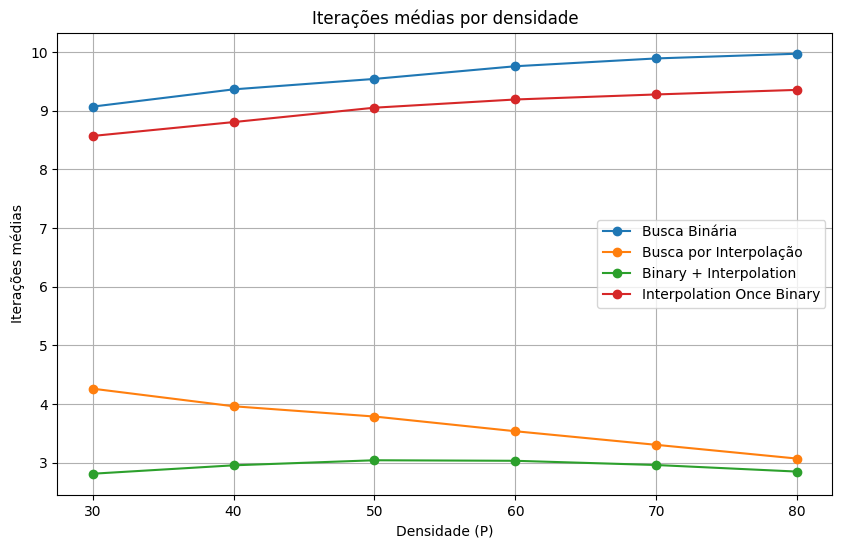

In [25]:
iteracoes_por_P = df.groupby("P").agg({
    "binary_iteracoes": "mean",
    "interpolation_iteracoes": "mean",
    "binary_interpolation_iteracoes": "mean",
    "interpolation_once_binary_iteracoes": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    iteracoes_por_P.index,
    iteracoes_por_P["binary_iteracoes"],
    marker="o",
    label="Busca Binária"
)

plt.plot(
    iteracoes_por_P.index,
    iteracoes_por_P["interpolation_iteracoes"],
    marker="o",
    label="Busca por Interpolação"
)

plt.plot(
    iteracoes_por_P.index,
    iteracoes_por_P["binary_interpolation_iteracoes"],
    marker="o",
    label="Binary + Interpolation"
)

plt.plot(
    iteracoes_por_P.index,
    iteracoes_por_P["interpolation_once_binary_iteracoes"],
    marker="o",
    label="Interpolation Once Binary"
)

plt.xlabel("Densidade (P)")
plt.ylabel("Iterações médias")
plt.title("Iterações médias por densidade")

plt.legend()
plt.grid(True)

plt.show()

In [26]:
# Iterações por tipo
df.groupby("tipo")[
    [
        "binary_iteracoes",
        "interpolation_iteracoes",
        "binary_interpolation_iteracoes",
        "interpolation_once_binary_iteracoes"
    ]
].mean()

,binary_iteracoes,interpolation_iteracoes,binary_interpolation_iteracoes,interpolation_once_binary_iteracoes
tipo,,,,
biased,9.596758,4.299247,3.000522,8.596544
cluster,9.606292,4.778389,3.481013,9.347521
fault,9.598736,3.010882,2.826037,9.157363
uniform,9.597501,2.529381,2.462818,9.067649


## Análise da influência das distribuições

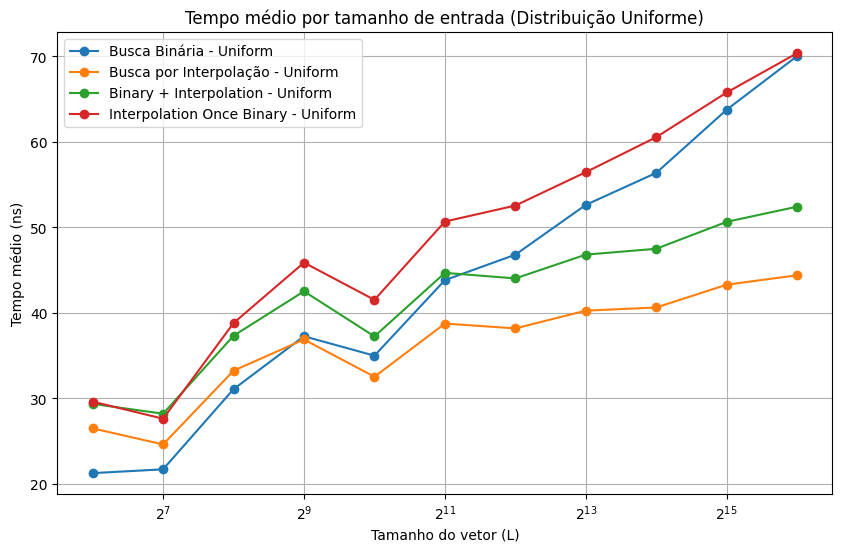

In [27]:
uniform_df = df[df['tipo'] == 'uniform']

tempo_por_L_uniform = uniform_df.groupby("L").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_L_uniform.index,
    tempo_por_L_uniform["binary_tempo_ns"],
    marker="o",
    label="Busca Binária - Uniform"
)

plt.plot(
    tempo_por_L_uniform.index,
    tempo_por_L_uniform["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação - Uniform"
)

plt.plot(
    tempo_por_L_uniform.index,
    tempo_por_L_uniform["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation - Uniform"
)

plt.plot(
    tempo_por_L_uniform.index,
    tempo_por_L_uniform["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary - Uniform"
)

plt.xlabel("Tamanho do vetor (L)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por tamanho de entrada (Distribuição Uniforme)")

plt.legend()
plt.xscale("log", base=2)
plt.grid(True)

plt.show()

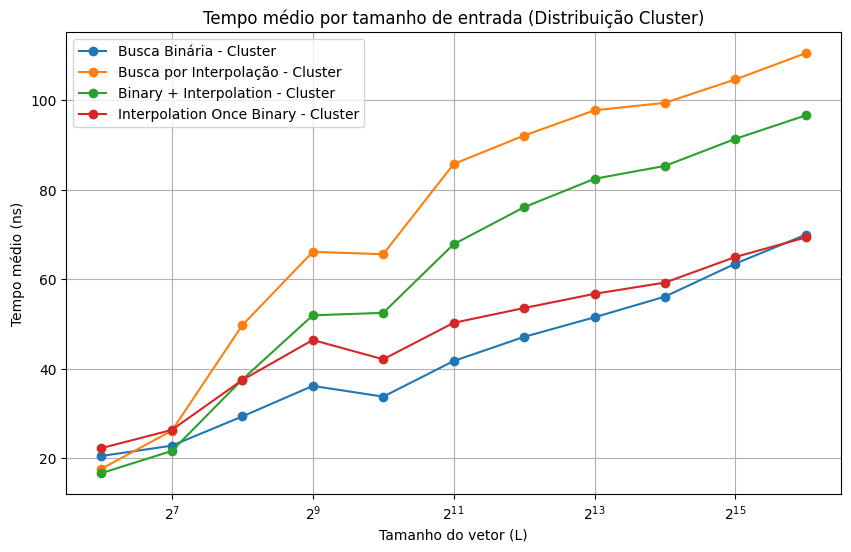

In [28]:
cluster_df = df[df['tipo'] == 'cluster']

tempo_por_L_cluster = cluster_df.groupby("L").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_L_cluster.index,
    tempo_por_L_cluster["binary_tempo_ns"],
    marker="o",
    label="Busca Binária - Cluster"
)

plt.plot(
    tempo_por_L_cluster.index,
    tempo_por_L_cluster["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação - Cluster"
)

plt.plot(
    tempo_por_L_cluster.index,
    tempo_por_L_cluster["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation - Cluster"
)

plt.plot(
    tempo_por_L_cluster.index,
    tempo_por_L_cluster["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary - Cluster"
)

plt.xlabel("Tamanho do vetor (L)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por tamanho de entrada (Distribuição Cluster)")

plt.legend()
plt.xscale("log", base=2)
plt.grid(True)

plt.show()

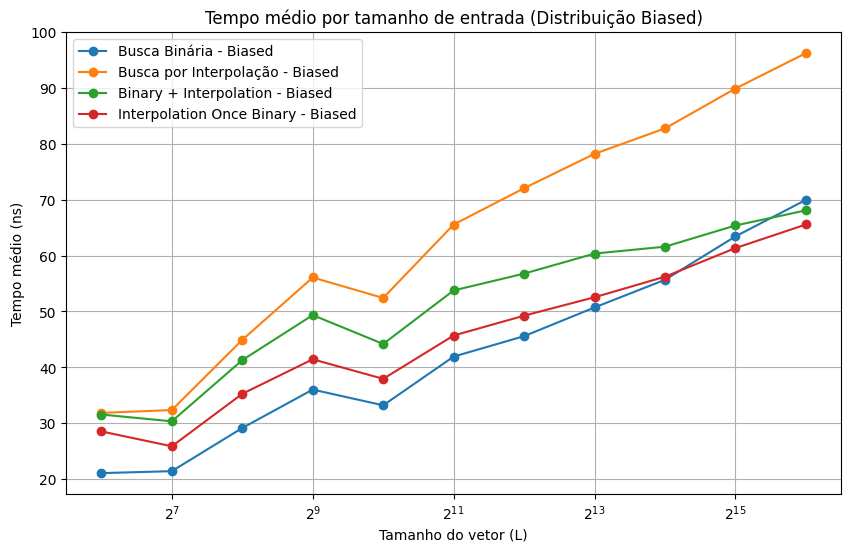

In [29]:
biased_df = df[df['tipo'] == 'biased']

tempo_por_L_biased = biased_df.groupby("L").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_L_biased.index,
    tempo_por_L_biased["binary_tempo_ns"],
    marker="o",
    label="Busca Binária - Biased"
)

plt.plot(
    tempo_por_L_biased.index,
    tempo_por_L_biased["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação - Biased"
)

plt.plot(
    tempo_por_L_biased.index,
    tempo_por_L_biased["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation - Biased"
)

plt.plot(
    tempo_por_L_biased.index,
    tempo_por_L_biased["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary - Biased"
)

plt.xlabel("Tamanho do vetor (L)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por tamanho de entrada (Distribuição Biased)")

plt.legend()
plt.xscale("log", base=2)
plt.grid(True)

plt.show()

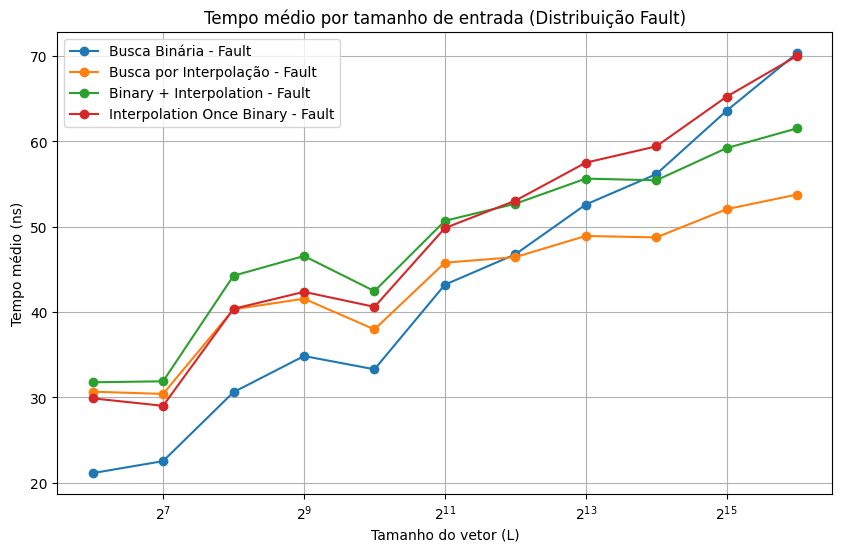

In [30]:
fault_df = df[df['tipo'] == 'fault']

tempo_por_L_fault = fault_df.groupby("L").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_L_fault.index,
    tempo_por_L_fault["binary_tempo_ns"],
    marker="o",
    label="Busca Binária - Fault"
)

plt.plot(
    tempo_por_L_fault.index,
    tempo_por_L_fault["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação - Fault"
)

plt.plot(
    tempo_por_L_fault.index,
    tempo_por_L_fault["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation - Fault"
)

plt.plot(
    tempo_por_L_fault.index,
    tempo_por_L_fault["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary - Fault"
)

plt.xlabel("Tamanho do vetor (L)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por tamanho de entrada (Distribuição Fault)")

plt.legend()
plt.xscale("log", base=2)
plt.grid(True)

plt.show()

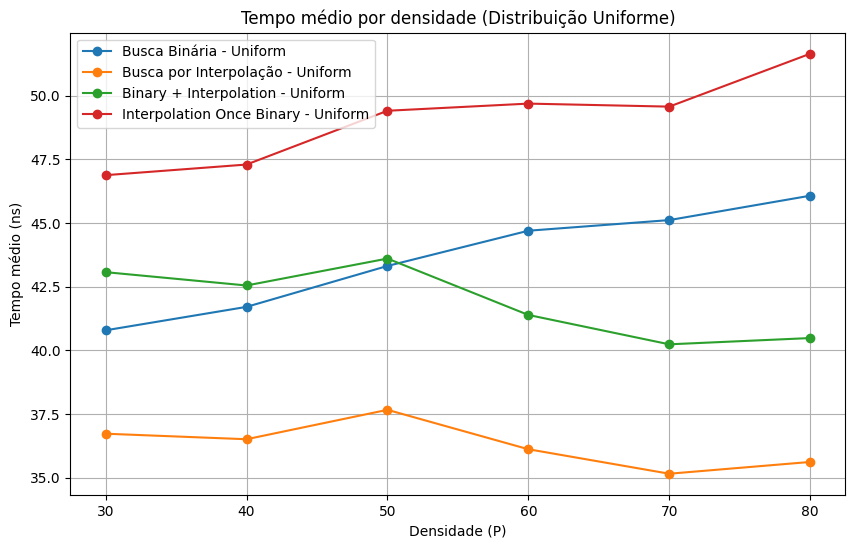

In [31]:
uniform_df_P = df[df['tipo'] == 'uniform']

tempo_por_P_uniform = uniform_df_P.groupby("P").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_P_uniform.index,
    tempo_por_P_uniform["binary_tempo_ns"],
    marker="o",
    label="Busca Binária - Uniform"
)

plt.plot(
    tempo_por_P_uniform.index,
    tempo_por_P_uniform["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação - Uniform"
)

plt.plot(
    tempo_por_P_uniform.index,
    tempo_por_P_uniform["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation - Uniform"
)

plt.plot(
    tempo_por_P_uniform.index,
    tempo_por_P_uniform["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary - Uniform"
)

plt.xlabel("Densidade (P)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por densidade (Distribuição Uniforme)")

plt.legend()
plt.grid(True)

plt.show()

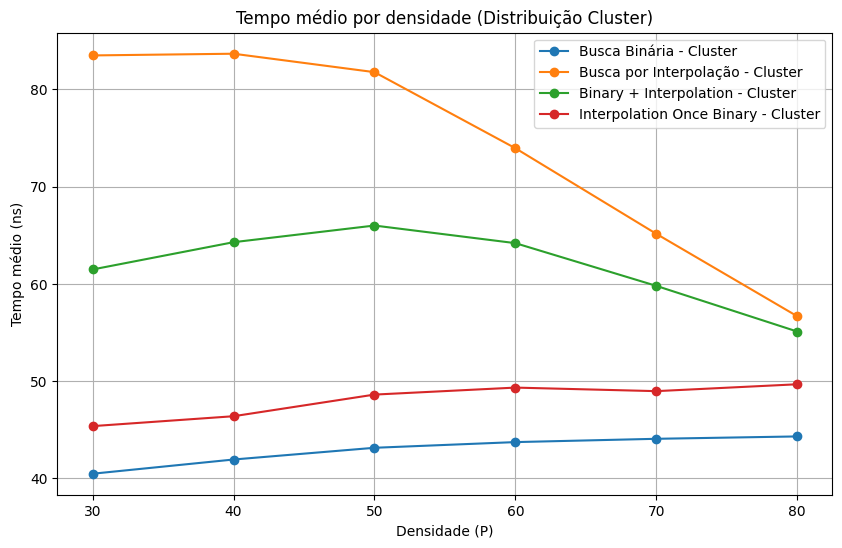

In [32]:
cluster_df_P = df[df['tipo'] == 'cluster']

tempo_por_P_cluster = cluster_df_P.groupby("P").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_P_cluster.index,
    tempo_por_P_cluster["binary_tempo_ns"],
    marker="o",
    label="Busca Binária - Cluster"
)

plt.plot(
    tempo_por_P_cluster.index,
    tempo_por_P_cluster["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação - Cluster"
)

plt.plot(
    tempo_por_P_cluster.index,
    tempo_por_P_cluster["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation - Cluster"
)

plt.plot(
    tempo_por_P_cluster.index,
    tempo_por_P_cluster["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary - Cluster"
)

plt.xlabel("Densidade (P)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por densidade (Distribuição Cluster)")

plt.legend()
plt.grid(True)

plt.show()

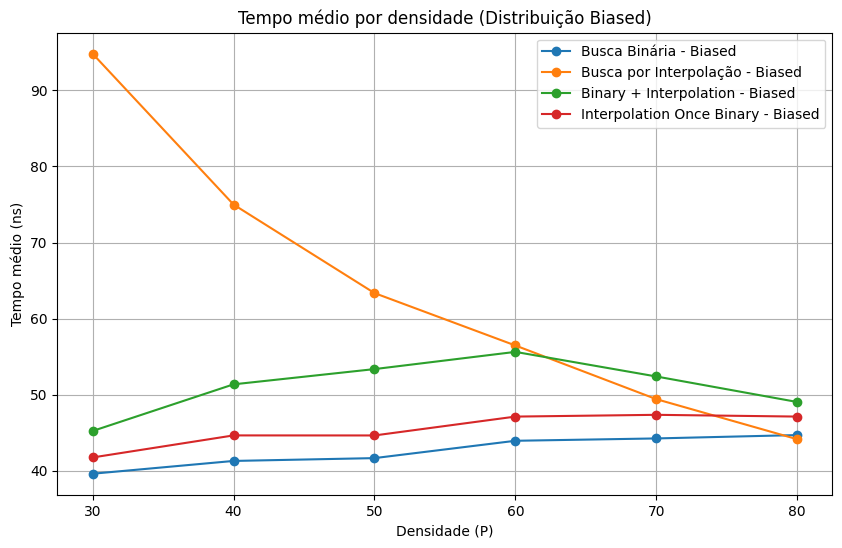

In [33]:
biased_df_P = df[df['tipo'] == 'biased']

tempo_por_P_biased = biased_df_P.groupby("P").agg({
    "binary_tempo_ns": "mean",
    "interpolation_tempo_ns": "mean",
    "binary_interpolation_tempo_ns": "mean",
    "interpolation_once_binary_tempo_ns": "mean"
})

plt.figure(figsize=(10,6))

plt.plot(
    tempo_por_P_biased.index,
    tempo_por_P_biased["binary_tempo_ns"],
    marker="o",
    label="Busca Binária - Biased"
)

plt.plot(
    tempo_por_P_biased.index,
    tempo_por_P_biased["interpolation_tempo_ns"],
    marker="o",
    label="Busca por Interpolação - Biased"
)

plt.plot(
    tempo_por_P_biased.index,
    tempo_por_P_biased["binary_interpolation_tempo_ns"],
    marker="o",
    label="Binary + Interpolation - Biased"
)

plt.plot(
    tempo_por_P_biased.index,
    tempo_por_P_biased["interpolation_once_binary_tempo_ns"],
    marker="o",
    label="Interpolation Once Binary - Biased"
)

plt.xlabel("Densidade (P)")
plt.ylabel("Tempo médio (ns)")
plt.title("Tempo médio por densidade (Distribuição Biased)")

plt.legend()
plt.grid(True)

plt.show()

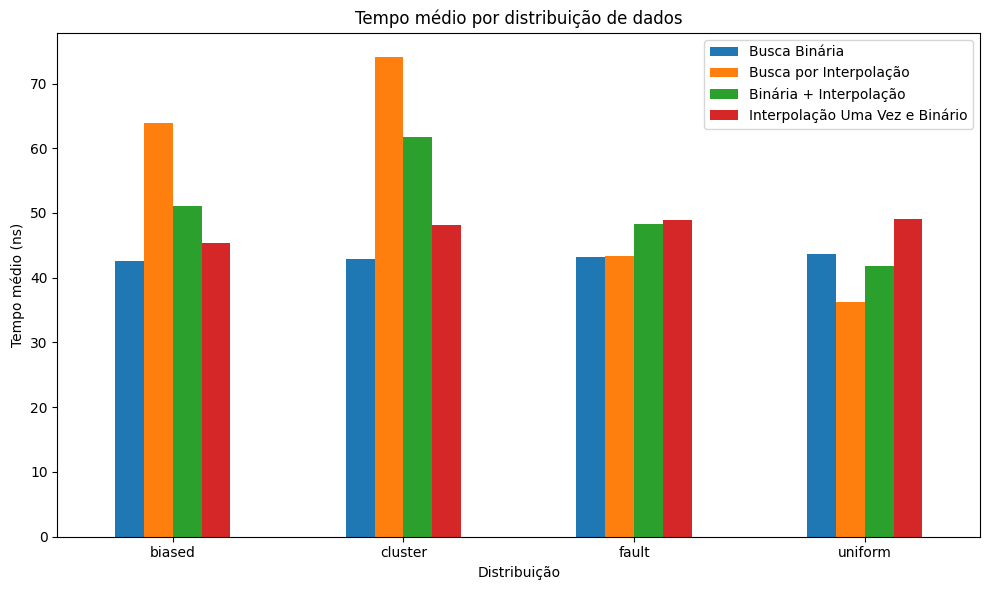

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

agrupado = df.groupby("tipo")[
[
    "binary_tempo_ns",
    "interpolation_tempo_ns",
    "binary_interpolation_tempo_ns",
    "interpolation_once_binary_tempo_ns"
]
].mean()

# Rename columns for consistent labels
agrupado.columns = [
    "Busca Binária",
    "Busca por Interpolação",
    "Binária + Interpolação",
    "Interpolação Uma Vez e Binário"
]

agrupado.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Tempo médio (ns)")
plt.xlabel("Distribuição")
plt.title("Tempo médio por distribuição de dados")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

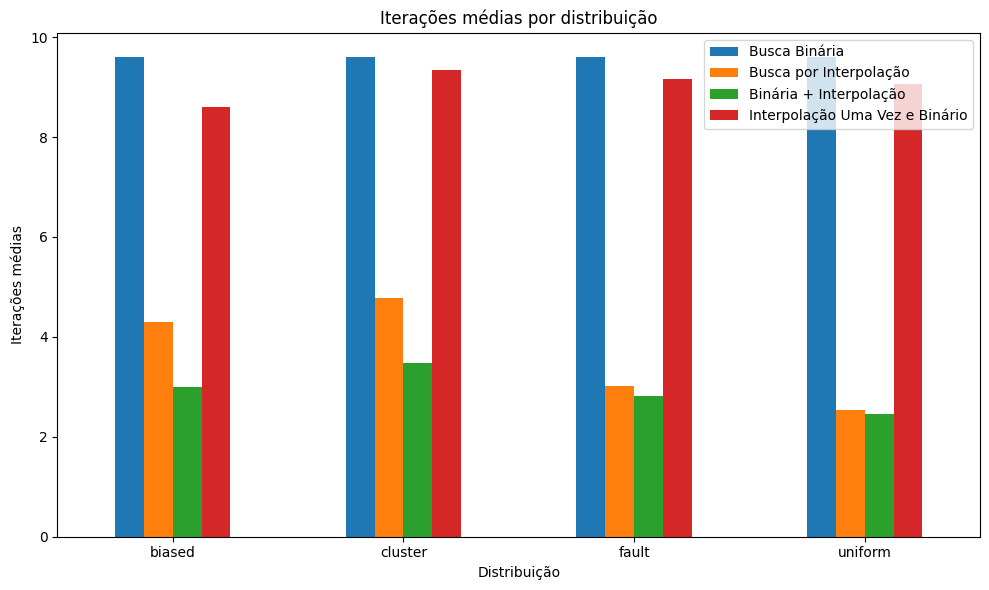

In [35]:
agrupado = df.groupby("tipo")[
[
    "binary_iteracoes",
    "interpolation_iteracoes",
    "binary_interpolation_iteracoes",
    "interpolation_once_binary_iteracoes"
]
].mean()

# Rename columns for consistent labels
agrupado.columns = [
    "Busca Binária",
    "Busca por Interpolação",
    "Binária + Interpolação",
    "Interpolação Uma Vez e Binário"
]

agrupado.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Iterações médias")
plt.xlabel("Distribuição")
plt.title("Iterações médias por distribuição")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()